In [1]:
%matplotlib inline

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib import gridspec
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from IPython.display import HTML

import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import re
import math
import baltic as bt

In [2]:
typeface = 'Arial'
mpl.rcParams['font.weight'] = 300
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

In [3]:
segments = {
    "Segment1": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment1.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment1.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment1.cds.state.glm.log"
                ],
        "color": "#4c72a5"
    },
    "Segment2": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment2.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment2.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment2.cds.state.glm.log"
                ],
        "color": "#48a365"
    },
    "Segment3": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment3.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment3.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment3.cds.state.glm.log"
                ],
        "color": "#d0694a"
    },
    "Segment4": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/2026_seg4_all.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/2026_seg4_all.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/2026_seg4_all.state.glm.log"
                ],
        "color": "#e1c72f"
    },
    "Segment5": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment5.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment5.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment5.cds.state.glm.log"
                ],
        "color": "#cc79a7"
    },
    "Segment6": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment6.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment6.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment6.cds.state.glm.log"
                ],
        "color": "#77bedb"
    },
    "Segment7": {
        "xml": "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment7.cds.xml",
        "logs": ["C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run01/segment7.cds.state.glm.log",
                 "C:/Users/iblag/Desktop/flud_res_2026/indreb-segments/run02/segment7.cds.state.glm.log"
                ],
        "color": "#7f6e85"
    }
}

In [4]:
def compute_hpd(samples, alpha=0.05):
    """
    Computes the highest posterior density (HPD) interval for a set of samples.

    Args:
        samples (array-like): Posterior samples from a distribution.
        alpha (float, optional): Significance level for the interval.
            Default is 0.05, corresponding to a 95% HPD interval.

    Returns:
        tuple: A tuple (lower, upper) containing:
            - lower (float): Lower bound of the HPD interval.
            - upper (float): Upper bound of the HPD interval.

    Docstring generated with ChatGPT 5.5.
    """
    samples = np.sort(samples)
    n = len(samples)
    interval_idx_inc = int(np.floor((1 - alpha) * n))
    n_intervals = n - interval_idx_inc
    interval_width = samples[interval_idx_inc:] - samples[:n_intervals]
    min_idx = np.argmin(interval_width)
    return samples[min_idx], samples[min_idx + interval_idx_inc]

In [5]:

all_results = {}

burnin = 10000000
trait = 'state'

for seg_name, seg_data in segments.items():

    print(f"\nProcessing {seg_name}")

    xml_path = seg_data["xml"]
    lpaths = seg_data["logs"]

    # Extract predictors from XML
    predictors = []
    design_matrix = 0

    for line in open(xml_path, 'r'):
        matrixRegex = r'\t+<parameter id="([A-Za-z0-9_.]+)" value="'
        if '<designMatrix' in line:
            design_matrix = 1
        if design_matrix:
            matrixID = re.search(matrixRegex, line)
            if matrixID is not None:
                predictors.append(matrixID.group(1))

    required_coeffs = ['%s.coefficients%d' % (trait, x + 1)
                       for x in range(len(predictors))]
    required_indicators = ['%s.coefIndicators%d' % (trait, x + 1)
                           for x in range(len(predictors))]

    GLM_coeffs = {x: [] for x in predictors}
    GLM_indicators = {x: [] for x in predictors}

    # Read GLM log files
    for log_path in lpaths:
        for line in open(log_path, 'r'):
            l = line.strip('\n').split('\t')

            if l[0] == 'state':
                header = l
                indices_coeffs = [i for i, x in enumerate(header)
                                  if x in required_coeffs]
                indices_indicators = [i for i, x in enumerate(header)
                                      if x in required_indicators]

            elif '#' in line:
                continue

            elif int(l[0]) >= burnin:
                for i, j, x in zip(indices_coeffs,
                                   indices_indicators,
                                   predictors):
                    GLM_coeffs[x].append(float(l[i]))
                    GLM_indicators[x].append(float(l[j]))

    # Compute statistics
    priorProbability = 1 - math.pow(0.5, (1 / float(len(predictors))))
    priorOdds = priorProbability / (1 - priorProbability)
    
    GLM_conditional_coeffs = {}
    indicator_samples = {}
    BFs = {}
    
    for x in predictors:
    
        indicators = GLM_indicators[x]
        coeffs = GLM_coeffs[x]
    
        support = np.mean(indicators)
    
        # Conditional beta distribution
        conditioned_coeff = [
            a for a, b in zip(coeffs, indicators)
            if b == 1.0
        ]
    
        # Bayes factor calculation
        n = len(indicators)
        posteriorOdds = ((support - (1 / n)) /
                         (1 - (support - (1 / n))))
        bf_value = posteriorOdds / priorOdds
    
        # Clean predictor name
        clean_name = x.replace("state.", "")
        clean_name = re.sub(r"^segment[0-9]+_", "", clean_name)
    
        # Store
        GLM_conditional_coeffs[clean_name] = conditioned_coeff
        indicator_samples[clean_name] = indicators.copy()
        BFs[clean_name] = bf_value
    
    
    # Store results per segment
    all_results[seg_name] = {
        "conditional": GLM_conditional_coeffs.copy(),  # list
        "indicator": indicator_samples.copy(),        # list (0/1 samples)
        "BF": BFs.copy()                              # scalar
    }


# Define unified predictor list

predictor_list = sorted(
    list(next(iter(all_results.values()))["conditional"].keys())
)



Processing Segment1

Processing Segment2

Processing Segment3

Processing Segment4

Processing Segment5

Processing Segment6

Processing Segment7


In [8]:
print("Bayes Factors and Conditional Mean Betas by Predictor across segments")

for predictor in predictor_list:
    print(f"\nPredictor: {predictor}")
    print("-" * (12 + len(predictor)))
    
    for seg_name, seg_data in all_results.items():
        
        bf = seg_data["BF"].get(predictor, float('nan'))
        
        cond_vals = seg_data["conditional"].get(predictor, [])
        
        # handle empty case safely
        if len(cond_vals) > 0:
            cond_mean = np.mean(cond_vals)
        else:
            cond_mean = float('nan')
        
        print(f"{seg_name:20s} : BF = {bf:.4f} | mean β = {cond_mean:.4f}")

Bayes Factors and Conditional Mean Betas by Predictor across segments

Predictor: GDP_per_capita_destination_logtransform
---------------------------------------------------
Segment1             : BF = 0.0166 | mean β = 0.1249
Segment2             : BF = 0.0116 | mean β = -0.1137
Segment3             : BF = 0.0099 | mean β = -0.0473
Segment4             : BF = 0.0265 | mean β = -0.0288
Segment5             : BF = 0.0182 | mean β = -0.0479
Segment6             : BF = 0.0265 | mean β = -0.0549
Segment7             : BF = 0.0083 | mean β = 0.0079

Predictor: GDP_per_capita_origin_logtransform
----------------------------------------------
Segment1             : BF = 0.1598 | mean β = -1.2374
Segment2             : BF = 0.0580 | mean β = -0.9938
Segment3             : BF = 0.0315 | mean β = -0.1634
Segment4             : BF = 0.0930 | mean β = -0.6071
Segment5             : BF = 0.0514 | mean β = 0.0305
Segment6             : BF = 0.1397 | mean β = -1.2810
Segment7             : BF = 0.024

18002
BF → inclusion probability mapping:
BF=3 → p=0.0915
BF=15 → p=0.3349
BF=50 → p=0.6266


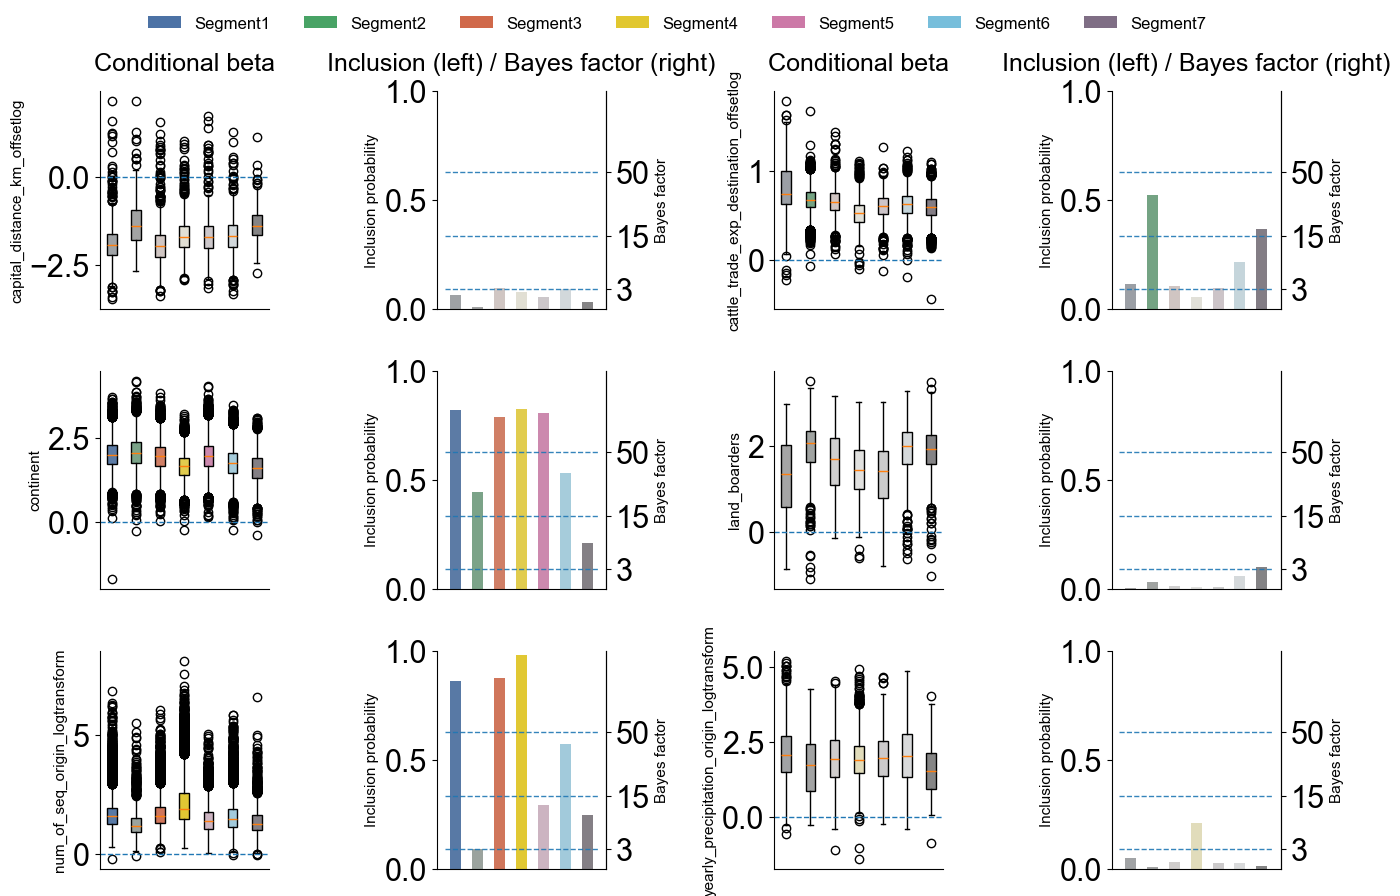

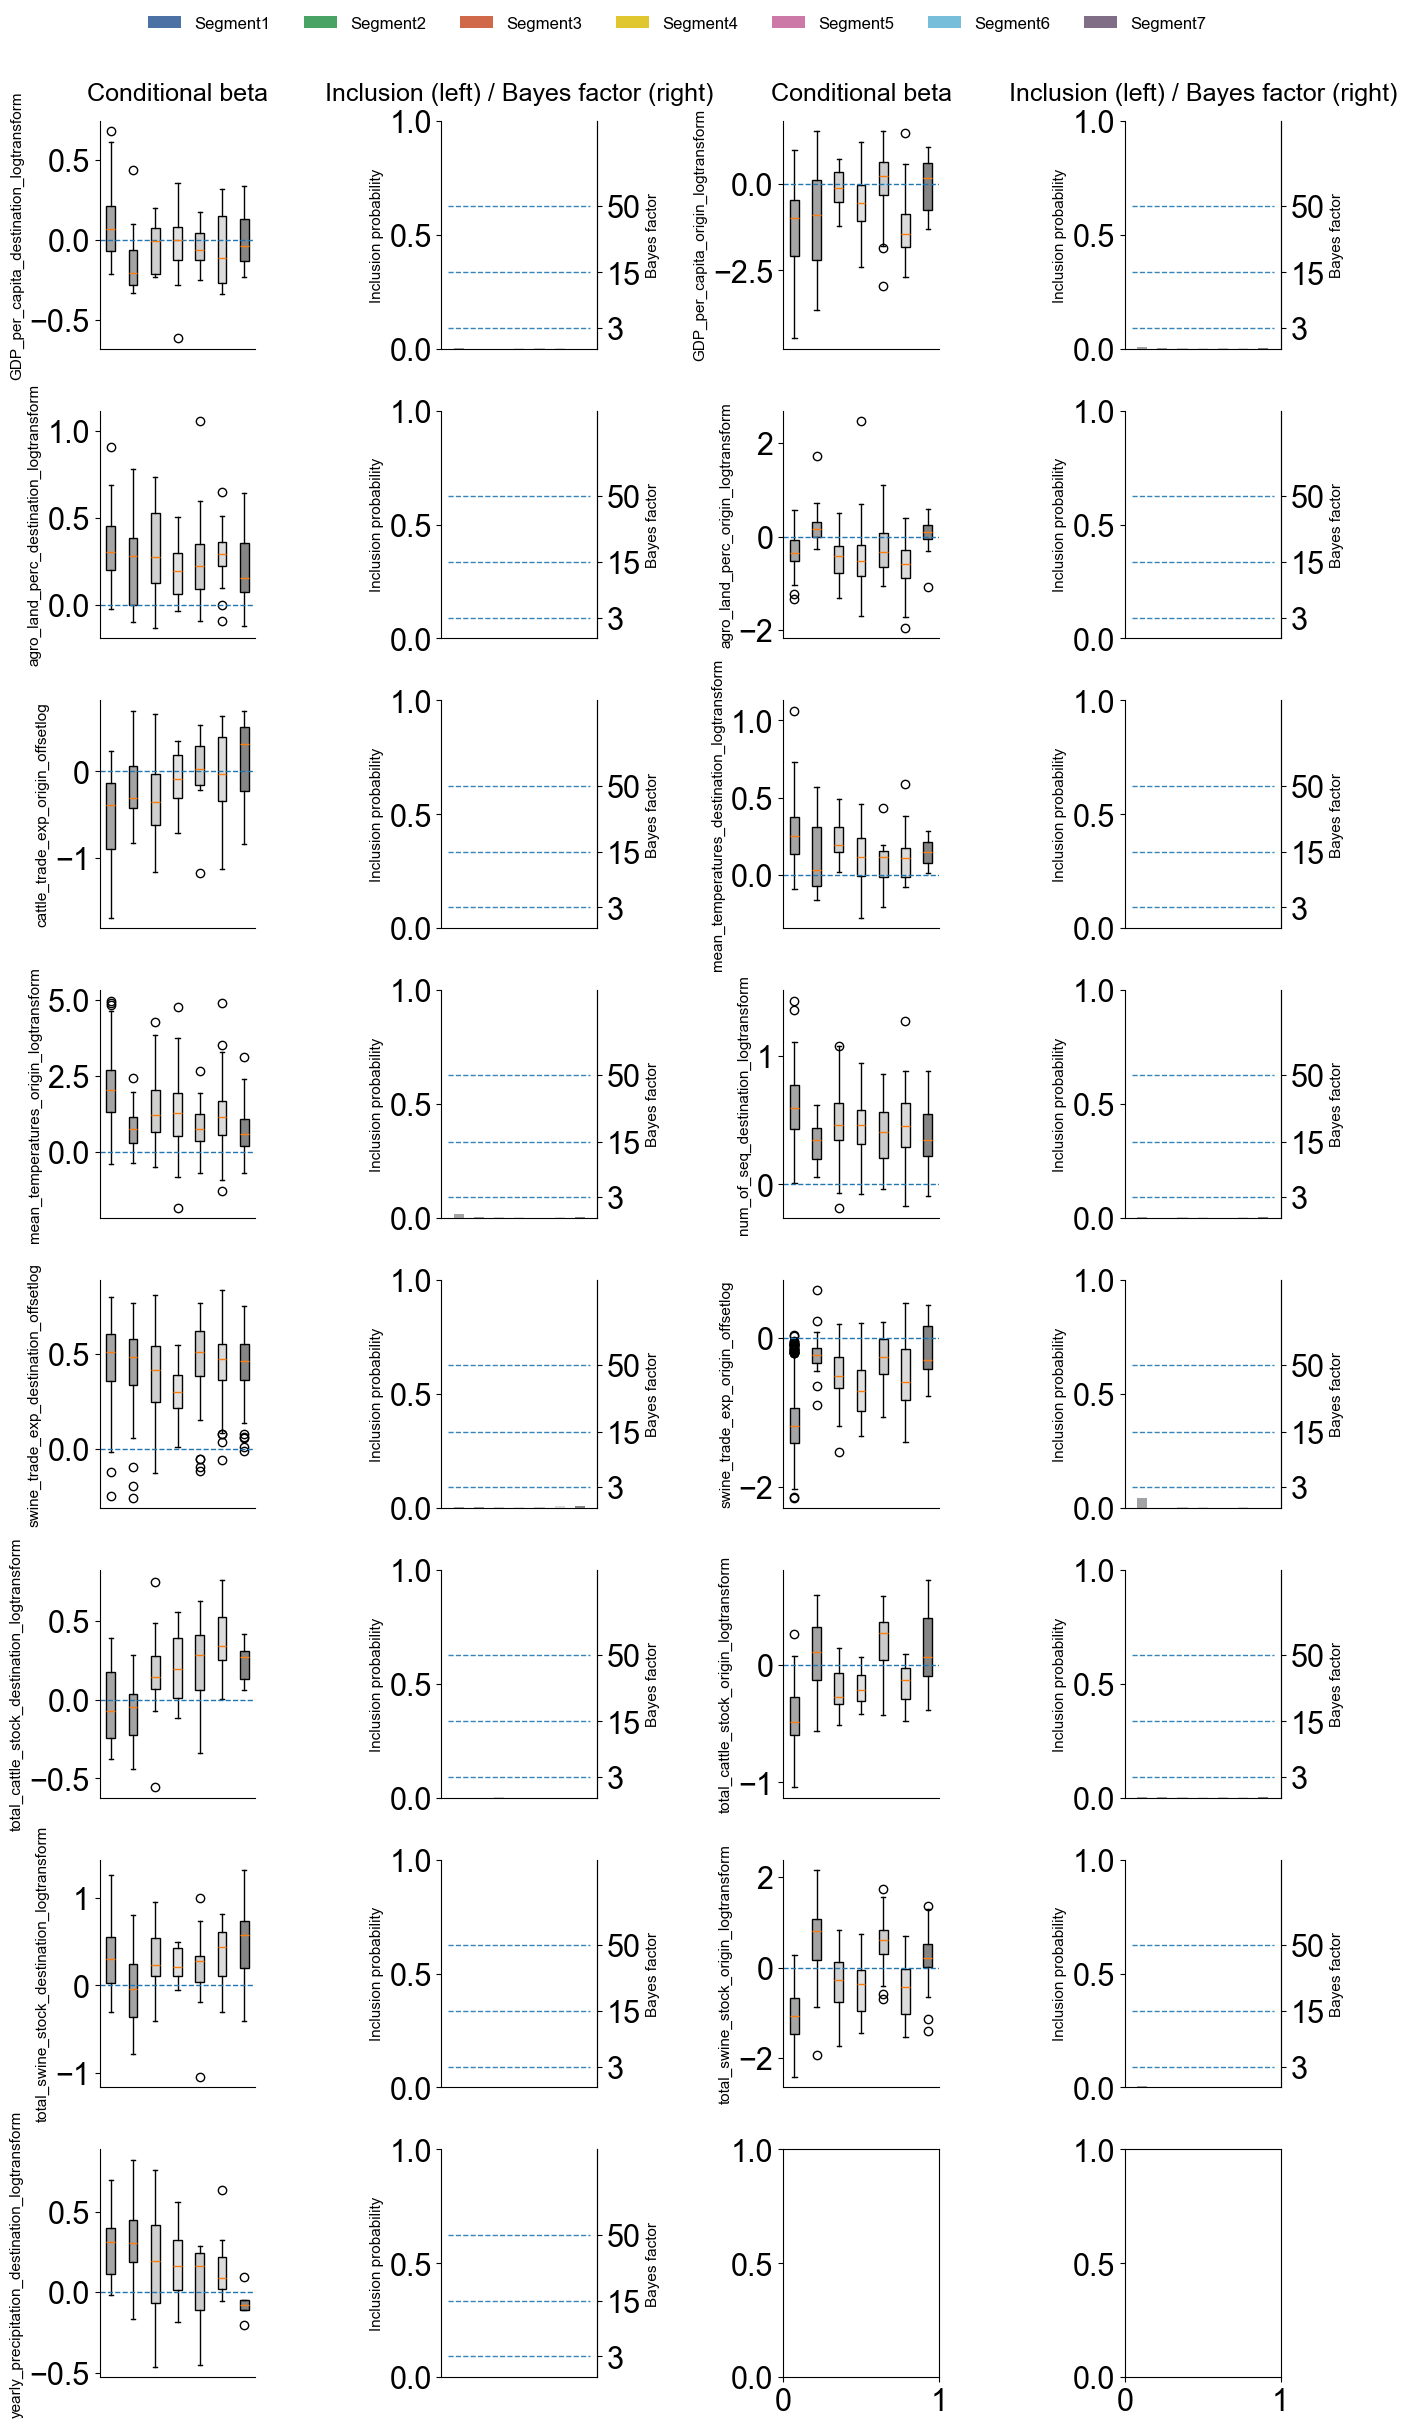

In [11]:
P = len(predictor_list)
n_segments = len(segments)
# Get n from any indicator sample
example_segment = list(all_results.keys())[0]
example_predictor = predictor_list[0]

L = len(all_results[example_segment]["indicator"][example_predictor])

print(L)

def prior_odds(P):
    def prior_odds(P):
    """
    Computes the prior odds of predictor inclusion under the
    Bayesian stochastic search variable selection prior.

    Args:
        P (int): Total number of predictors.

    Returns:
        float: Prior odds of inclusion.

    Docstring generated with ChatGPT 5.5.
    """
    return (1 - 0.5**(1 / P)) / (0.5**(1 / P))

def bf_to_inclusion_prob(BF, P, L):
    """
    Converts a Bayes factor to a posterior inclusion probability.

    Args:
        BF (float): Bayes factor for predictor inclusion.
        P (int): Total number of predictors.
        L (int): Number of posterior samples.

    Returns:
        float: Posterior inclusion probability corresponding
            to the supplied Bayes factor.

    Docstring generated with ChatGPT 5.5.
    """
    po = prior_odds(P)
    return (1 / L) + (BF * po) / (1 + BF * po)

def inclusion_prob_to_bf(p, P, L):
    """
    Converts a posterior inclusion probability to a Bayes factor.

    Args:
        p (float): Posterior inclusion probability.
        P (int): Total number of predictors.
        L (int): Number of posterior samples.

    Returns:
        float: Bayes factor corresponding to the supplied
            inclusion probability.

    Docstring generated with ChatGPT 5.5.
    """
    po = prior_odds(P)
    x = p - (1 / L)
    x = np.clip(x, 1e-10, 1 - 1e-10)
    return (x / (1 - x)) / po

# BF Thresholds
bf_ticks = [3, 15, 50]
bf_probs = [bf_to_inclusion_prob(bf, P, L) for bf in bf_ticks]

print("BF → inclusion probability mapping:")
for bf, p in zip(bf_ticks, bf_probs):
    print(f"BF={bf} → p={p:.4f}")

# Split predictors by BF
predictors_high = []
predictors_low = []

for predictor in predictor_list:
    bf_values = [
        all_results[s]["BF"][predictor]
        for s in segments.keys()
    ]
    
    if any(bf >= 3 for bf in bf_values):
        predictors_high.append(predictor)
    else:
        predictors_low.append(predictor)

groups = [
    ("BF ≥ 3 (at least one segment)", predictors_high),
    ("BF < 3 (all segments)", predictors_low)
]

# plot
def plot_group(predictor_subset, title):
    """
    Plots conditional beta distributions, inclusion probabilities,
    and Bayes factors for a subset of predictors across segments.

    Args:
        predictor_subset (list): List of predictor names to plot.
        title (str): Title describing the predictor group.

    Returns:
        None: Displays the generated matplotlib figure.

    Docstring generated with ChatGPT 5.5.
    """

    if len(predictor_subset) == 0:
        return

    n_rows = int(np.ceil(len(predictor_subset) / 2))

    fig, axes = plt.subplots(
        n_rows, 4,
        figsize=(14, 3 * n_rows),
        sharex=False
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, predictor in enumerate(predictor_subset):

        row = i // 2
        col_offset = (i % 2) * 2

        segment_names = list(segments.keys())
        base_colors = [segments[s]["color"] for s in segment_names]

        inclusion_means = [
            np.mean(all_results[s]["indicator"][predictor])
            for s in segment_names
        ]

        # Color scaling
        colors = []
        for c, inc in zip(base_colors, inclusion_means):
            rgb = np.array(mcolors.to_rgb(c))
            hsv = mcolors.rgb_to_hsv(rgb)
            hsv[1] = hsv[1] * inc
            colors.append(mcolors.hsv_to_rgb(hsv))

        # Conditional beta
        ax = axes[row, col_offset + 0]

        beta_data = [
            all_results[s]["conditional"][predictor]
            for s in segment_names
        ]

        bp = ax.boxplot(beta_data, patch_artist=True, widths=0.4)

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xticks([])
        ax.spines[['top', 'right']].set_visible(False)

        if row == 0:
            ax.set_title("Conditional beta", pad=15, fontsize=18)

        ax.set_ylabel(predictor.replace("state.", ""), fontsize=11)

        # Inclusion and BF
        ax = axes[row, col_offset + 1]

        ax.bar(
            range(n_segments),
            inclusion_means,
            color=colors,
            width=0.5
        )

        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.spines[['top']].set_visible(False)

        if row == 0:
            ax.set_title("Inclusion (left) / Bayes factor (right)", pad=15, fontsize=18)

        # LEFT axis = inclusion probability
        ax.set_ylabel("Inclusion probability", fontsize=11)

        # RIGHT axis = Bayes factor
        secax = ax.secondary_yaxis(
            'right',
            functions=(
                lambda p: inclusion_prob_to_bf(p, P, L),
                lambda bf: bf_to_inclusion_prob(bf, P, L)
            )
        )

        secax.set_yticks(bf_ticks)
        secax.set_yticklabels([str(bf) for bf in bf_ticks])
        secax.set_ylabel("Bayes factor", fontsize=11)


        ymin, ymax = ax.get_ylim()
        
        for bf in bf_ticks:
            p = bf_to_inclusion_prob(bf, P, L)
        
            # Only draw if within visible range
            if ymin <= p <= ymax:
                ax.hlines(
                    y=p,
                    xmin=-0.5,
                    xmax=n_segments - 0.5,
                    linestyles="--",
                    linewidth=1,
                    alpha=0.9
                )
        

    legend_handles = [
        Patch(facecolor=segments[s]["color"], label=s)
        for s in segment_names
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(segment_names),
        frameon=False,
        fontsize=12
    )


    plt.tight_layout()
    plt.show()


for title, group_predictors in groups:
    plot_group(group_predictors, title)